In [3]:
import pandas as pd
listings=pd.read_csv("listings.csv.gz")
calendar=pd.read_csv("calendar.csv.gz")
reviews=pd.read_csv("reviews.csv.gz")

In [7]:
listings.shape

(96871, 79)

In [8]:
calendar.shape

(35357974, 7)

In [9]:
reviews.shape

(2097996, 6)

In [10]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [11]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,4.93,4.60,4.65,NaN,f,1,1,0,0,0.53
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,4.46,4.85,4.54,NaN,t,2,2,0,0,0.09


In [12]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96871 entries, 0 to 96870
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            96871 non-null  int64  
 1   listing_url                                   96871 non-null  object 
 2   scrape_id                                     96871 non-null  int64  
 3   last_scraped                                  96871 non-null  object 
 4   source                                        96871 non-null  object 
 5   name                                          96871 non-null  object 
 6   description                                   94421 non-null  object 
 7   neighborhood_overview                         41208 non-null  object 
 8   picture_url                                   96865 non-null  object 
 9   host_id                                       96871 non-null 

In [13]:
listings.isnull().sum().sort_values(ascending=False)

neighbourhood_group_cleansed    96871
calendar_updated                96871
license                         96871
neighborhood_overview           55663
neighbourhood                   55662
                                ...  
maximum_nights_avg_ntm              0
availability_30                     0
availability_60                     0
availability_90                     0
amenities                           0
Length: 79, dtype: int64

In [19]:
important_cols=[
    "price",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "amenities",
    "review_scores_rating",
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "neighbourhood_group_cleansed"
]
listings[important_cols].head()

,price,room_type,property_type,accommodates,bedrooms,bathrooms,amenities,review_scores_rating,estimated_revenue_l365d,estimated_occupancy_l365d,neighbourhood_group_cleansed
0,$70.00,Private room,Private room in rental unit,1,1.0,1.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",4.85,6440.0,92,NaN
1,$149.00,Entire home/apt,Entire rental unit,2,1.0,1.0,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",4.80,1341.0,9,NaN
2,$411.00,Entire home/apt,Entire rental unit,6,3.0,2.0,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",4.77,0.0,0,NaN
3,NaN,Entire home/apt,Entire townhouse,2,1.0,NaN,"[""Self check-in"", ""Kitchen"", ""Apple speaker Bl...",4.90,NaN,14,NaN
4,$210.00,Entire home/apt,Entire condo,4,1.0,1.0,"[""Washer"", ""Kitchen"", ""TV with standard cable""...",4.53,12600.0,60,NaN


In [20]:
listings[
[
    "price",
    "estimated_revenue_l365d",
    "review_scores_rating"
]
].describe()

,estimated_revenue_l365d,review_scores_rating
count,6.196300e+04,72749.000000
mean,1.047348e+04,4.684719
std,6.612429e+04,0.494191
min,0.000000e+00,0.000000
25%,0.000000e+00,4.580000
50%,2.968000e+03,4.830000
75%,1.225000e+04,5.000000
max,1.015000e+07,5.000000


In [21]:
listings["room_type"].value_counts()

room_type
Entire home/apt    62907
Private room       33643
Shared room          212
Hotel room           109
Name: count, dtype: int64

In [22]:
listings["property_type"].value_counts().head(20)

property_type
Entire rental unit                    41215
Private room in rental unit           14464
Private room in home                  11704
Entire home                            9120
Entire condo                           8250
Private room in condo                  3189
Entire serviced apartment              1874
Private room in townhouse              1195
Room in hotel                          1113
Entire townhouse                       1058
Private room in bed and breakfast       491
Private room in guesthouse              377
Entire loft                             341
Entire guesthouse                       221
Room in boutique hotel                  217
Entire guest suite                      177
Private room in guest suite             174
Private room in loft                    153
Private room in serviced apartment      132
Private room                            103
Name: count, dtype: int64

In [40]:
listings["neighbourhood_group_cleansed"].value_counts().head(20)

Series([], Name: count, dtype: int64)

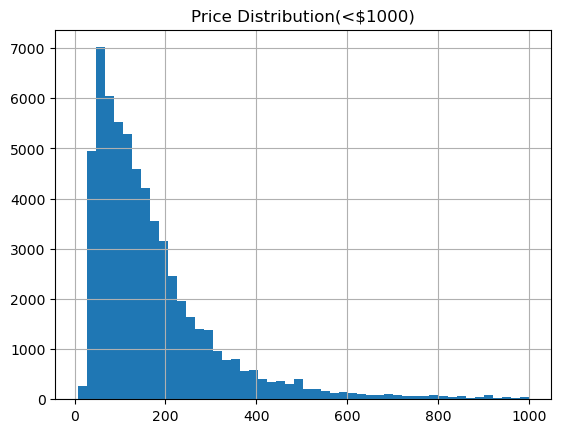

In [35]:
import matplotlib.pyplot as plt
listings[
    listings["price"]<1000
]["price"].hist(bins=50)
plt.title("Price Distribution(<$1000)")
plt.show()

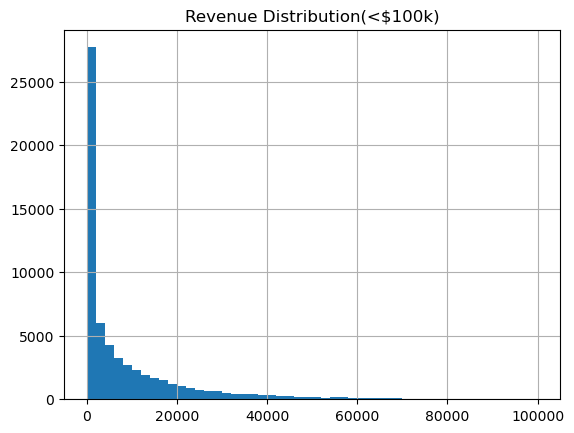

In [45]:
listings[
    listings["estimated_revenue_l365d"]<100000
]["estimated_revenue_l365d"].hist(bins=50)
plt.title("Revenue Distribution(<$100k)")
plt.show()

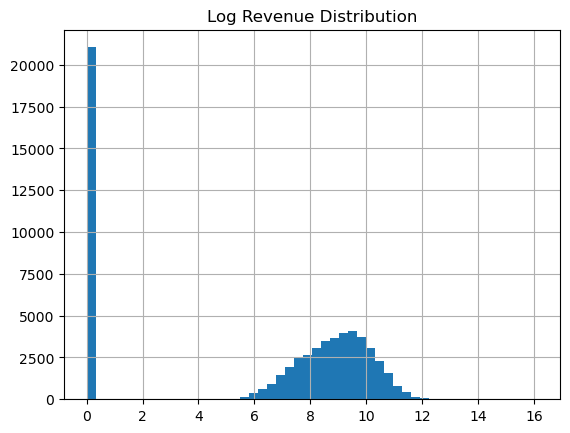

In [39]:
import numpy as np
np.log1p(
        listings["estimated_revenue_l365d"]
).hist(bins=50)
plt.title("Log Revenue Distribution")
plt.show()

In [36]:
(listings["estimated_revenue_l365d"] > 500000).sum()

15

In [37]:
listings[
    listings["estimated_revenue_l365d"] > 500000
][
    [
        "name",
        "price",
        "estimated_revenue_l365d",
        "estimated_occupancy_l365d"
    ]
].head(20)

,name,price,estimated_revenue_l365d,estimated_occupancy_l365d
742,"Über-clean, very private, double-deluxe, Chiswick",4332.0,675792.0,156
31553,Close To London Eye (TUR),6666.0,1413192.0,212
41301,Walk To London Eye - Double Room (FIL),11412.0,730368.0,64
51162,Twin Room Close to London Eye (RHI),50000.0,10100000.0,202
54442,Close To London Eye,65000.0,585000.0,9
55413,Stylish Earl's Court Getaway,9999.0,2549745.0,255
57204,Close to London Eye (BOL),58000.0,10150000.0,175
58354,Close To Waterloo & London Eye (CHA),5000.0,1240000.0,248
68167,Close to The Shard (TAI),10001.0,1470147.0,147
69137,Short Walk to London Eye (TOK),28000.0,1792000.0,64


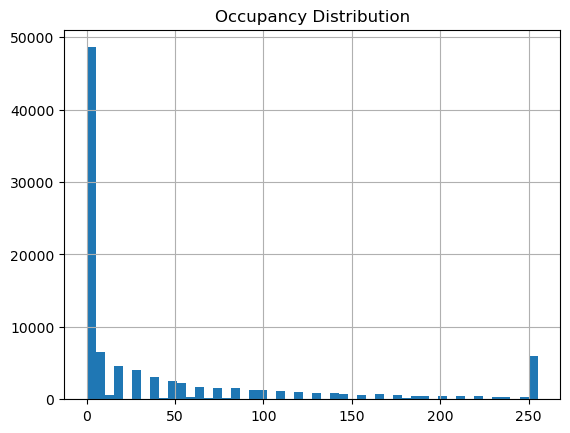

In [29]:
listings["estimated_occupancy_l365d"].hist(bins=50)
plt.title("Occupancy Distribution")
plt.show()

In [32]:
listings["price"].head()

0     $70.00
1    $149.00
2    $411.00
3        NaN
4    $210.00
Name: price, dtype: object

In [33]:
listings["price"]=(
    listings["price"]
    .str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
    .astype(float)
)

In [44]:
corr=listings[
[
    "price",
    "accommodates",
    "bedrooms",
    "review_scores_rating",
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d"
]
].corr()

corr

,price,accommodates,bedrooms,review_scores_rating,estimated_revenue_l365d,estimated_occupancy_l365d
price,1.000000,0.018609,0.021513,-0.012322,0.094566,-0.011289
accommodates,0.018609,1.000000,0.741649,-0.036284,0.064714,0.034715
bedrooms,0.021513,0.741649,1.000000,0.029882,0.042690,-0.091026
review_scores_rating,-0.012322,-0.036284,0.029882,1.000000,0.018730,0.074602
estimated_revenue_l365d,0.094566,0.064714,0.042690,0.018730,1.000000,0.189159
estimated_occupancy_l365d,-0.011289,0.034715,-0.091026,0.074602,0.189159,1.000000


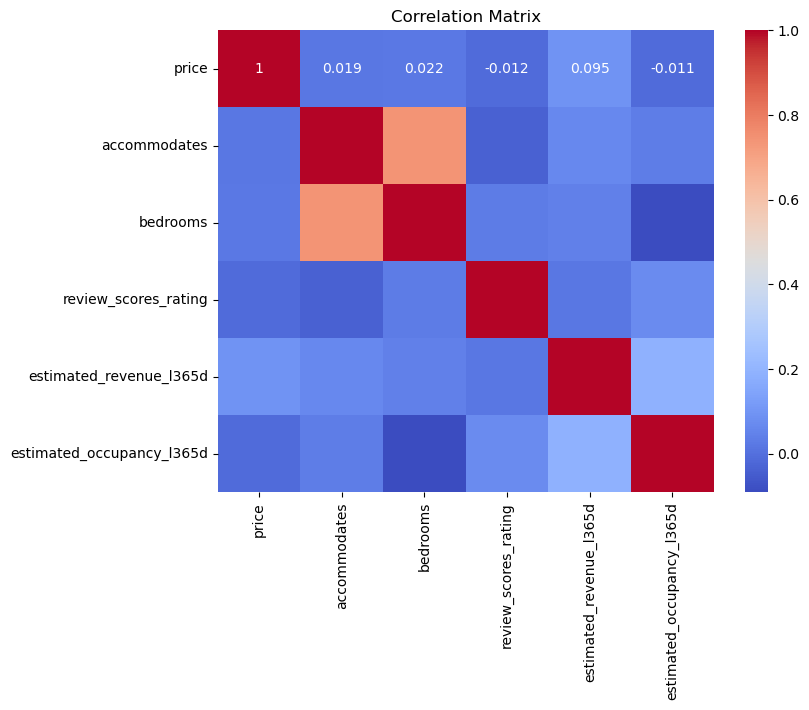

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [46]:
listings["price"].describe()

count    6.196300e+04
mean     2.299170e+02
std      4.437589e+03
min      7.000000e+00
25%      7.700000e+01
50%      1.350000e+02
75%      2.210000e+02
max      1.085147e+06
Name: price, dtype: float64

In [47]:
listings["estimated_revenue_l365d"].describe()

count    6.196300e+04
mean     1.047348e+04
std      6.612429e+04
min      0.000000e+00
25%      0.000000e+00
50%      2.968000e+03
75%      1.225000e+04
max      1.015000e+07
Name: estimated_revenue_l365d, dtype: float64

In [48]:
listings["estimated_occupancy_l365d"].describe()

count    96871.000000
mean        45.999381
std         74.930487
min          0.000000
25%          0.000000
50%          0.000000
75%         60.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64